In [2]:
#=============================================================================================================================
# CREDIT SCORING - EXPLICABILITÉ SHAP
#==============================================================================================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import warnings
import os
import joblib
warnings.filterwarnings('ignore')

models_dir = os.path.join(os.path.expanduser('~'),
                          'credit_scoring_project', 'models')

best_model = joblib.load(os.path.join(models_dir, 'xgboost_final.pkl'))

processed_dir = os.path.join(os.path.expanduser('~'),
                             'credit_scoring_project', 'data',
                             'processed')

X = pd.read_csv(os.path.join(processed_dir, 'X_preprocessed.csv'))
y = pd.read_csv(os.path.join(processed_dir, 'y_preprocessed.csv')).squeeze()


print("✅ Modéles et données importés avec succès")
print(f"X : {X.shape}")

✅ Modéles et données importés avec succès
X : (307511, 181)


In [6]:
X_sample = X.sample(1000, random_state=42)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_sample)

print("✅Valeurs SHAP calculées")
print(f"Shape des valeurs SHAP : {shap_values.shape}")

✅Valeurs SHAP calculées
Shape des valeurs SHAP : (1000, 181)


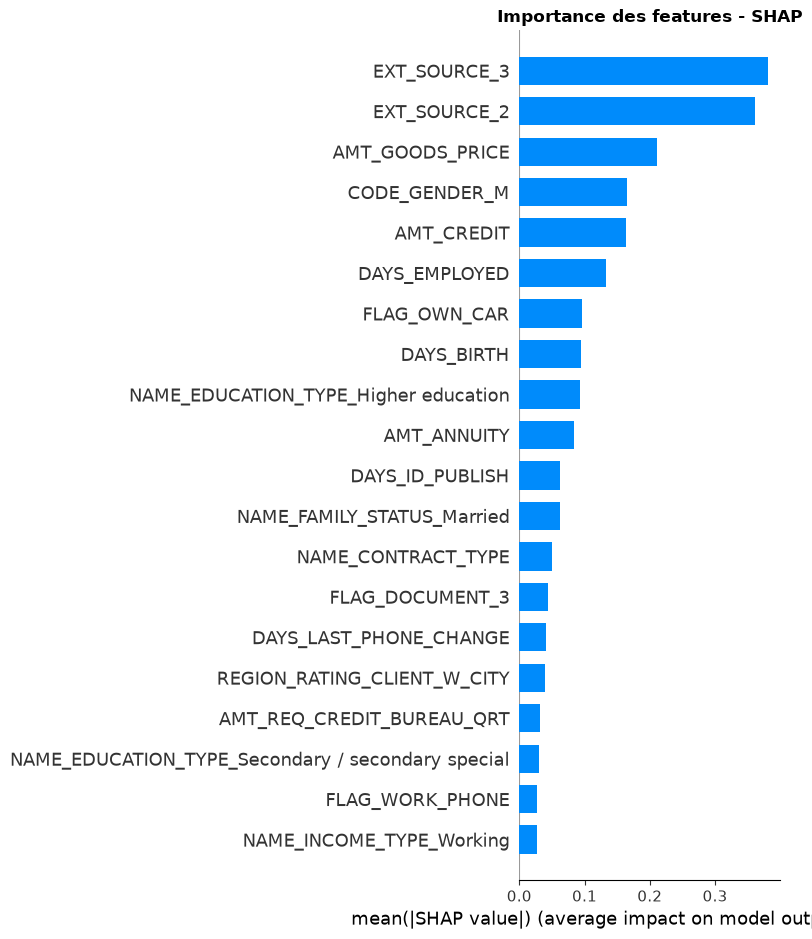

In [9]:
images_dir = os.path.join(os.path.expanduser('~'),
                          'credit_scoring_project',
                          'images')
plt.figure()
shap.summary_plot(shap_values, X_sample,
                  plot_type="bar",
                  max_display=20,
                  show=False)
plt.title('Importance des features - SHAP', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(images_dir, '11_shap_summary_bar.png'),
            dpi=150, bbox_inches='tight')
plt.show()

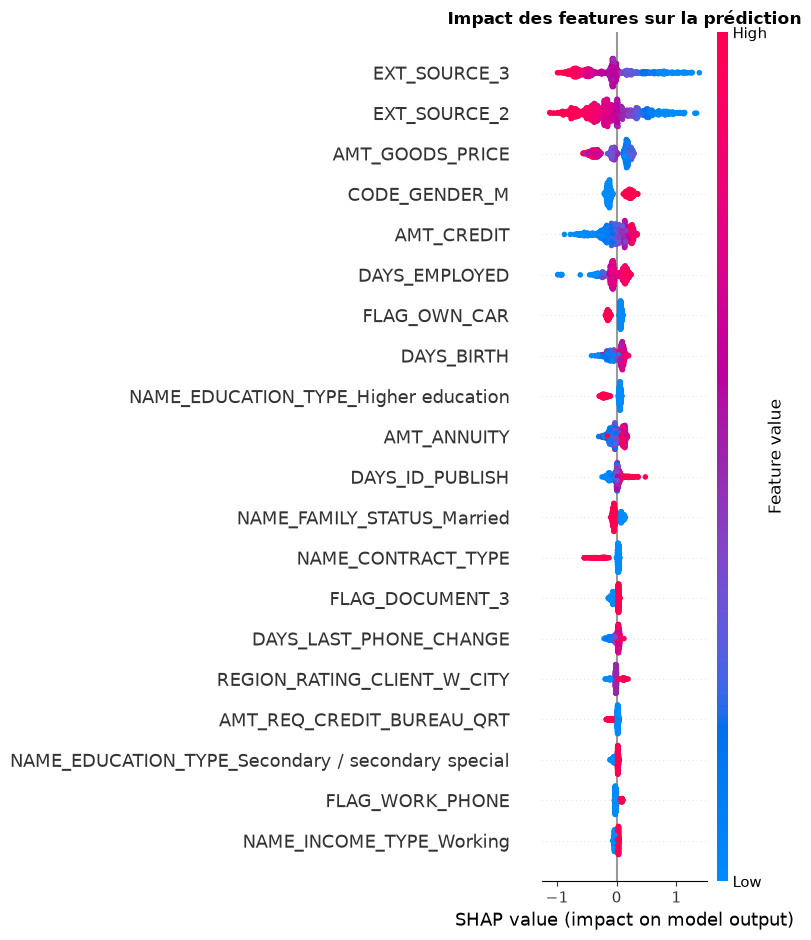

In [10]:
plt.figure()
shap.summary_plot(shap_values, X_sample,
                  max_display=20,
                  show=False)
plt.title('Impact des features sur la prédiction', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(images_dir, '12_shap_beeswarm.png'),
            dpi=150, bbox_inches='tight')
plt.show()

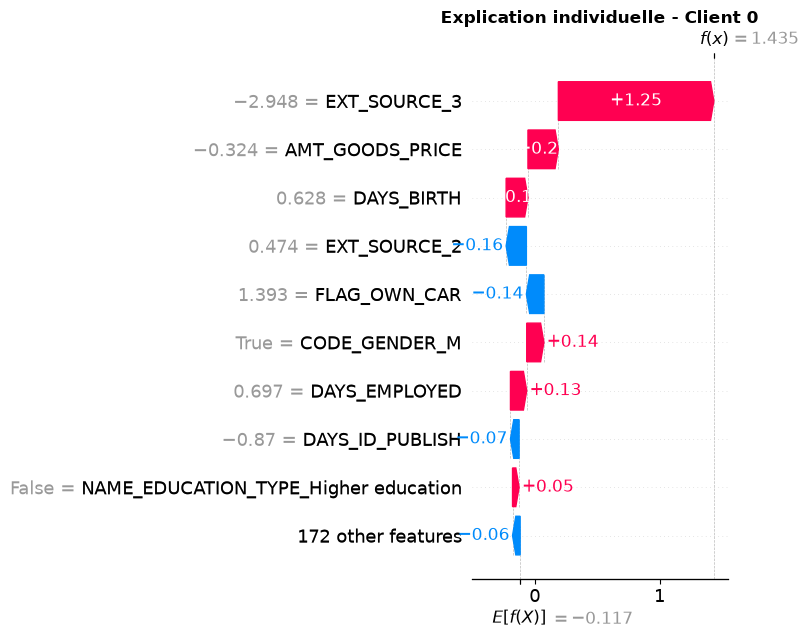

In [11]:
client_index=0

plt.figure()
shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[client_index],
        base_values=explainer.expected_value,
        data=X_sample.iloc[client_index],
        feature_names=X_sample.columns.tolist()
    ),
    show=False
)
plt.title('Explication individuelle - Client 0', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(images_dir, '13_shap_waterfall.png'),
            dpi=150, bbox_inches='tight')
plt.show()